# Oxygen-vacancy descriptor ML: revision analysis

## Purpose

This notebook rebuilds the descriptor-based ML analysis for compositionally modified layered LiCoO$_2$-based surfaces. It is designed to be readable, auditable, and shareable among the project team.

The central question is not simply whether a machine-learning model can approximate DFT. Rather, the analysis asks what information about oxygen-vacancy formation is already encoded in the oxygen-stoichiometric (pristine) structure, how that inference changes for withheld chemical families, and whether a limited set of explicit defect-response descriptors adds predictive information on the subset where those descriptors are available.

### Guardrails for interpretation

- `Evac` is a calculated oxygen-vacancy formation energy, not a prediction of experimental oxygen release or cathode degradation.
- The primary models use **pristine descriptors only**. Post-vacancy descriptors are used only in the explicitly limited 48-structure defect-response analysis.
- A random-forest model is an interpolation tool. Performance on a randomly split test set does not establish transfer to new chemical families.
- The primary representation excludes the spin-summary descriptors `3S` and `tot_S`; they are evaluated only as a sensitivity analysis because the labels arise from 0 K magnetic DFT states.
- The historical `Residual` column is never a feature. If residuals are analyzed, they are rebuilt from out-of-fold pristine-model predictions.
- Every fitted preprocessing/feature-selection step occurs inside the relevant training fold.

This is an analysis notebook, not a manuscript generator. It saves result tables and figures that can then be inspected before any scientific conclusion is written.

## How to use this notebook

1. Upload the two curated files produced for this revision:
   - `descriptorsV3_ML_curated.csv` (full pristine-descriptor dataset; 531 rows expected)
   - `vac-descriptorsV2_labeled.xlsx` (post-vacancy descriptor subset; 48 rows expected)
2. Run the setup, upload, and audit sections first. Do not run modeling if the audit reports unexpected rows, missing values, or ambiguous labels.
3. The default `RUN_MODE = "manuscript"` performs repeated nested validation. Run cells sequentially and archive the output folder. `pilot` and `high_precision` remain available for troubleshooting or a later sensitivity check.
4. Read results as a set of tests, not as a feature-ranking contest. The primary comparison is among predefined, physically motivated descriptor representations.

The notebook installs `openpyxl` to read the Excel subset. SHAP is optional and is not used to select the manuscript descriptor set.

In [3]:
# `openpyxl` reads the 48-row vacancy-descriptor Excel file. SHAP is optional
# and not installed automatically because it is not used for feature selection.
!pip -q install openpyxl

In [4]:
import hashlib
import json
import os
import platform
import re
import sys
from collections import Counter
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 180)
sns.set_theme(context='notebook', style='whitegrid')

## Configuration and reproducibility

The seed is fixed so that a result can be regenerated. Repetition still matters: the outer cross-validation repeats use different, fixed seeds and report the distribution of out-of-fold errors rather than one favorable split.

The full metal arrangement (the label after the `Li...__` prefix) is the grouping unit. Thus, lithiation siblings with the same metal arrangement cannot appear on opposite sides of a train/test split. The legacy `label` field remains a plotting label only; it is never used to define validation groups.

In [5]:
SEED = 20260915
# Default manuscript setting: 5 grouped outer folds repeated 3 times, with
# 5-fold inner tuning. This is more stringent than the completed pilot while
# remaining practical for a Colab session run one analysis cell at a time.
# Use `high_precision` only if we later need an additional 5-repeat check.
RUN_MODE = 'manuscript'  # Allowed values: 'pilot', 'manuscript', 'high_precision'
RUN_SHAP = False                 # Optional explanatory analysis; not used for feature selection.
RUN_DEFECT_RESIDUAL_ANALYSIS = False  # Enable only after inspecting the 48-row subset audit.

if RUN_MODE == 'pilot':
    OUTER_SPLITS = 3
    OUTER_REPEATS = 1
    INNER_SPLITS = 3
    N_SEARCH = 4
    N_ESTIMATORS = 150
    N_BOOTSTRAP = 300
elif RUN_MODE == 'manuscript':
    OUTER_SPLITS = 5
    OUTER_REPEATS = 3
    INNER_SPLITS = 5
    N_SEARCH = 12
    N_ESTIMATORS = 300
    N_BOOTSTRAP = 3000
elif RUN_MODE == 'high_precision':
    OUTER_SPLITS = 5
    OUTER_REPEATS = 5
    INNER_SPLITS = 5
    N_SEARCH = 20
    N_ESTIMATORS = 500
    N_BOOTSTRAP = 5000
else:
    raise ValueError("RUN_MODE must be 'pilot', 'manuscript', or 'high_precision'.")

RESULTS_DIR = Path(f'oxygen_vacancy_ml_results_{RUN_MODE}')
RESULTS_DIR.mkdir(exist_ok=True)

print({
    'python': sys.version.split()[0],
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'scikit-learn': sklearn.__version__,
    'RUN_MODE': RUN_MODE,
    'outer_folds_x_repeats': f'{OUTER_SPLITS} x {OUTER_REPEATS}',
    'results_directory': str(RESULTS_DIR.resolve()),
})

{'python': '3.13.15', 'pandas': '2.2.3', 'numpy': '2.1.3', 'scikit-learn': '1.6.1', 'RUN_MODE': 'manuscript', 'outer_folds_x_repeats': '5 x 3', 'results_directory': '/content/oxygen_vacancy_ml_results_manuscript'}


## Upload the curated inputs

This cell accepts the files by upload in Colab. If the notebook is run outside Colab, place them in the working directory. File names are matched flexibly, but the audit prints the exact files used. The source files are never overwritten.

In [6]:
try:
    from google.colab import files
    print('Colab detected. Upload the curated full and vacancy-subset files now.')
    uploaded = files.upload()
except ImportError:
    print('Not running in Colab. Place the two files in the current working directory.')


def locate_input(patterns):
    candidates = []
    for pattern in patterns:
        candidates.extend(Path('.').glob(pattern))
    candidates = sorted(set(candidates), key=lambda p: p.name)
    if not candidates:
        raise FileNotFoundError(f'No file found for patterns: {patterns}')
    # Prefer the revision names if several files are present.
    preferred = [p for p in candidates if 'V3_ML_curated' in p.name or 'V2_labeled' in p.name]
    return preferred[0] if preferred else candidates[0]


FULL_PATH = locate_input(['*V3_ML_curated*.csv', '*curated*.csv'])
VAC_PATH = locate_input(['*V2_labeled*.xlsx', '*labeled*.xlsx'])
print('Full pristine dataset:', FULL_PATH)
print('Vacancy-subset dataset:', VAC_PATH)

Colab detected. Upload the curated full and vacancy-subset files now.


Saving descriptorsV3_ML_curated.csv to descriptorsV3_ML_curated.csv
Saving vac-descriptorsV2_labeled.xlsx to vac-descriptorsV2_labeled.xlsx
Full pristine dataset: descriptorsV3_ML_curated.csv
Vacancy-subset dataset: vac-descriptorsV2_labeled.xlsx


In [7]:
full = pd.read_csv(FULL_PATH)
vac = pd.read_excel(VAC_PATH)


def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for block in iter(lambda: f.read(1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()


provenance = {
    'full_file': FULL_PATH.name,
    'full_sha256': sha256(FULL_PATH),
    'vacancy_file': VAC_PATH.name,
    'vacancy_sha256': sha256(VAC_PATH),
    'seed': SEED,
    'run_mode': RUN_MODE,
}
with open(RESULTS_DIR / 'provenance.json', 'w') as f:
    json.dump(provenance, f, indent=2)

print('Full shape:', full.shape, '| vacancy subset shape:', vac.shape)
print('Full SHA-256:', provenance['full_sha256'])
print('Vacancy-subset SHA-256:', provenance['vacancy_sha256'])
display(full.head(3))

Full shape: (531, 109) | vacancy subset shape: (48, 68)
Full SHA-256: 73539c6c50e8938edb0defb97008fce7d46253446f829022a55028a3bb148e4d
Vacancy-subset SHA-256: 8bc42fd5acd11a6556dc9e239a7c882a6b0fc07abbbf935b0db8ce41191bef68


,source_excel_row,structure_label,label,Evac,Modification,E_form,E_fermi,E_bg,VBM,CBM,Lix,3OS,3S,3Hdp,3Z,Z_surf,nelect,nelect_no_o,nelect_m_only,wtd_nelect,e_tot,tot_OS,tot_S,tot_Hdp,O_M1,O_M2,O_M3,BL_avg,M1_charge,M2_charge,M3_charge,avg_M_charge,O_charge,sum_qm-qo,total_LCE_charge,Vm,Vo,Vm-o,Eoxm,wtd_Vm,wtd_Vo,M1_chi,M2_chi,M3_chi,sum_chi,avg_chi,M1_bc_full,M1_bc_occ,M1_bc_unocc,M1_band_width,M1_occ_bw,M2_bc_full,M2_bc_occ,M2_bc_unocc,M2_band_width,M2_occ_bw,M3_bc_full,M3_bc_occ,M3_bc_unocc,M3_band_width,M3_occ_bw,O(p)_bc_full,O(p)_bc_occ,O(p)_bc_unocc,O(p)_cbm_diff,O(p)_band_width,O(p)_occ_bw,M1_t2g,M1_eg,M2_t2g,M2_eg,M3_t2g,M3_eg,M1_ion_e,M1_min_pol,M1_pol,M1_max_pol,M2_ion_e,M2_min_pol,M2_pol,M2_max_pol,M3_ion_e,M3_min_pol,M3_pol,M3_max_pol,avg_ion_e,M1_bin_evac,M2_bin_evac,M3_bin_evac,avg_bin_evac,M1_avg_intensity,M2_avg_intensity,M3_avg_intensity,LCE_avg_intensity,avg_val_full,avg_val_occ,avg_val_unocc,avg_band_width,avg_occ_bw,full_bc_diff,occ_bc_diff,M1_std_pot,M2_std_pot,M3_std_pot,avg_std_pot,elec_wtd_bc_occ,elec_wtd_bw_occ,int_wtd_bc_occ,int_wtd_bw_occ
0,2,Li1.00__P0Co-P1Ni-P2Co-P3Co-P4Co-P5Co__P6Co-P7...,Ni,3.698265,1-2-3-Ni-Co-Co,-120.458368,2.700694,0.2273,2.5904,2.8177,1.0,6.748545,0.735814,1.283721,82,163,398.000001,182.000001,164.000001,114.800001,123.587415,40.412585,1.635531,7.778802,2.109095,1.967725,1.940897,2.005906,9.265,8.301,8.382,8.649333,5.006,20.942,30.954,12.930079,7.496805,5.433274,64.727977,4.31375,2.493520,1.53,1.56,1.56,4.65,1.55,-2.157690,-2.741958,0.738066,2.602560,2.465949,-1.371319,-2.293021,1.189125,2.913269,2.882327,-1.323225,-2.290305,1.389823,3.003195,2.940100,-3.398754,-4.016863,1.437966,6.216454,2.392754,1.745019,4.612929,3.552386,3.802991,3.373356,3.868234,3.327482,7.639878,46.0,49.0,52.0,7.881010,51.0,55.0,59.0,7.881010,51.0,55.0,59.0,7.800633,2.026178,2.483149,2.483149,2.330825,0.441898,0.359974,0.373673,0.391848,-1.617411,-2.441762,1.105671,2.839675,2.762792,1.781342,1.575101,-0.257,-0.280,-0.280,-0.272333,-2.454820,2.749945,-2.460917,2.744171
1,3,Li1.00__P0Co-P1Co-P2Ni-P3Co-P4Co-P5Co__P6Co-P7...,Ni,3.722331,1-2-3-Co-Ni-Co,-120.509463,2.680256,0.1691,2.6034,2.7725,1.0,6.710100,0.771519,1.243728,82,163,398.000002,182.000002,164.000002,114.800002,123.972053,40.027947,1.647621,7.423496,1.948030,2.113460,1.948983,2.003491,8.354,9.232,8.371,8.652333,5.005,20.952,30.962,12.951687,7.505422,5.446265,64.823192,4.31925,2.496510,1.56,1.53,1.56,4.65,1.55,-1.372076,-2.322105,1.286034,2.967766,2.914537,-2.139947,-2.717060,0.693559,2.579338,2.451970,-1.322420,-2.285844,1.374655,2.990183,2.928016,-3.420591,-4.051281,1.436356,6.193091,2.407690,1.744910,3.839006,3.349918,4.505687,3.647722,3.877691,3.313014,7.881010,51.0,55.0,59.0,7.639878,46.0,49.0,52.0,7.881010,51.0,55.0,59.0,7.800633,2.483149,2.026178,2.483149,2.330825,0.371534,0.441000,0.373614,0.395383,-1.611481,-2.441669,1.118083,2.845763,2.764841,1.809110,1.609612,-0.280,-0.257,-0.280,-0.272333,-2.452576,2.752444,-2.457524,2.746804
2,4,Li1.00__P0Co-P1Co-P2Co-P3Ni-P4Co-P5Co__P6Co-P7...,Ni,3.372990,1-2-3-Co-Co-Ni,-120.295773,2.821603,0.2649,2.6875,2.9524,1.0,7.050694,0.670041,1.587584,82,163,398.000002,182.000002,164.000002,114.800001,122.204370,41.795630,1.426363,9.219307,1.948560,1.975163,2.114535,2.012753,8.365,8.309,9.302,8.658667,4.999,20.977,30.975,12.898730,7.460527,5.438203,64.480752,4.30407,2.481442,1.56,1.56,1.53,4.65,1.55,-1.515326,-2.467722,1.159278,2.979837,2.925597,-1.544334,-2.473592,1.035388,2.919762,2.882463,-2.275795,-2.872711,0.678127,2.641783,2.498929,-3.495217,-4.100916,1.251026,6.447617,2.380653,1.762154,3.849009,3.346977,3.778585,3.396159,4.637448,3.530066,7.881010,51.0,55.0,59.0,7.881010,51.0,55.0,59.0,7.639878,46.0,49.0,52.0,7.800633,2.483149,2.483149,2.026178,2.330825,0.370207,0.365468,0.455327,0.397001,-1.778485,-2.604675,0.957597,2.847127,2.768996,1.716732,1.496241,-0.280,-0.280,-0.257,-0.272333,-2.616540,2.757079,-2.624353,2.749243


## Data audit: stop here if this fails

The curation step retained the lower `Evac` member of twelve nominally structurally identical duplicate pairs as a **working analysis choice**, pending the separate spin-state/convergence review. This notebook does not re-decide that choice; it records and analyzes the curated table supplied to it.

The audit checks expected identifiers, targets, labels, duplicates, and missing numerical values. It also confirms that every row can be assigned to a parent metal arrangement for grouped validation.

In [8]:
REQUIRED_FULL = {'Evac', 'E_form', 'Lix', 'label', 'Modification', 'source_excel_row', 'structure_label'}
REQUIRED_VAC = {'Evac', 'Lix', 'label', 'Modification', 'source_excel_row', 'vac_source_excel_row', 'structure_label'}

missing_full = REQUIRED_FULL - set(full.columns)
missing_vac = REQUIRED_VAC - set(vac.columns)
assert not missing_full, f'Missing required full-data columns: {missing_full}'
assert not missing_vac, f'Missing required vacancy-subset columns: {missing_vac}'
assert full['structure_label'].notna().all(), 'Full dataset has missing structure labels.'
assert vac['structure_label'].notna().all(), 'Vacancy subset has missing structure labels.'

def parent_from_structure_label(s):
    s = str(s)
    return s.split('__', 1)[1] if '__' in s else s

full['parent_id'] = full['structure_label'].map(parent_from_structure_label)
vac['parent_id'] = vac['structure_label'].map(parent_from_structure_label)

# `label` was supplied for plotting. The LOFO family is constructed directly
# from the structure-generation convention: P1–P3 are the three LCE metal
# pairs. Site permutations are grouped by their unordered composition.
LCE_POSITIONS = (1, 2, 3)
def lce_composition_family(structure_label):
    parsed = {int(i): element for i, element in re.findall(r'P(\d+)([A-Z][a-z]?)', str(structure_label))}
    missing = [i for i in LCE_POSITIONS if i not in parsed]
    if missing:
        raise ValueError(f'Could not parse LCE positions {missing} from: {structure_label}')
    counts = {}
    for pos in LCE_POSITIONS:
        counts[parsed[pos]] = counts.get(parsed[pos], 0) + 1
    return 'LCE_' + '_'.join(f'{element}{count}' for element, count in sorted(counts.items()))

full['plot_label'] = full['label'].astype(str)
vac['plot_label'] = vac['label'].astype(str)
full['lce_composition_family'] = full['structure_label'].map(lce_composition_family)
vac['lce_composition_family'] = vac['structure_label'].map(lce_composition_family)

print('Rows / unique parent metal arrangements:', len(full), full['parent_id'].nunique())
print('Lix levels:', sorted(full['Lix'].dropna().unique()))
print('LCE-composition family counts (used only for LOFO):')
display(full['lce_composition_family'].value_counts().rename_axis('lce_composition_family').to_frame('n'))
print('Exact duplicate full rows:', int(full.duplicated().sum()))
print('Duplicate structure labels (expected only across Lix):', int(full['structure_label'].duplicated().sum()))
print('Missing values among numeric full columns:', int(full.select_dtypes(include=np.number).isna().sum().sum()))
print('Vacancy-subset source rows present in full:', vac['source_excel_row'].isin(full['source_excel_row']).all())

audit_summary = pd.DataFrame({
    'dataset': ['full_pristine', 'vacancy_subset'],
    'n_rows': [len(full), len(vac)],
    'n_columns': [full.shape[1], vac.shape[1]],
    'n_unique_parent_ids': [full.parent_id.nunique(), vac.parent_id.nunique()],
    'n_LCE_composition_families': [full.lce_composition_family.nunique(), vac.lce_composition_family.nunique()],
    'n_unique_structure_labels': [full.structure_label.nunique(), vac.structure_label.nunique()],
})
display(audit_summary)
audit_summary.to_csv(RESULTS_DIR / 'audit_summary.csv', index=False)

Rows / unique parent metal arrangements: 531 336
Lix levels: [np.float64(0.67), np.float64(0.78), np.float64(0.89), np.float64(1.0)]
LCE-composition family counts (used only for LOFO):


,n
lce_composition_family,
LCE_Co2_Ni1,28
LCE_Co2_Mn1,28
LCE_Co2_Fe1,28
LCE_Al1_Co2,28
LCE_Co1_Ni2,28
LCE_Co1_Mn2,28
LCE_Co1_Fe2,28
LCE_Al2_Co1,28
LCE_Co1_Mn1_Ni1,22


Exact duplicate full rows: 0
Duplicate structure labels (expected only across Lix): 0
Missing values among numeric full columns: 0
Vacancy-subset source rows present in full: True


,dataset,n_rows,n_columns,n_unique_parent_ids,n_LCE_composition_families,n_unique_structure_labels
0,full_pristine,531,112,336,38,531
1,vacancy_subset,48,71,48,16,48


## Define descriptor representations before fitting models

Feature representations are defined from physical provenance rather than selected by looking at the final test folds:

| Representation | Purpose |
|---|---|
| R0 | A minimal baseline: lithiation only (plus a mean-only dummy model). |
| R1 | Direct pristine descriptors, excluding spin-summary and binary-vacancy reference values. |
| R2 | R1 plus pristine `E_form`; tests the value of a pristine thermodynamic quantity. |
| R3 | R2 plus binary vacancy reference values for the three LCE sites; tests the value of simple reference chemistry. |
| R1-spin | A sensitivity comparison that adds `3S` and `tot_S`; not the primary model. |

`E_form` is modeled separately as a positive control. The `E_form` model does not use `E_form` itself, `Evac`, or binary vacancy references. The cell prints every selected feature list so that the team can check provenance before fitting.

In [9]:
TARGETS = {'Evac', 'E_form'}
METADATA = {
    'label', 'Modification', 'source_excel_row', 'structure_label',
    'parent_id', 'plot_label', 'lce_composition_family'
}
SPIN_FEATURES = [c for c in ['3S', 'tot_S'] if c in full.columns]
BINARY_REFERENCE_FEATURES = [
    c for c in ['M1_bin_evac', 'M2_bin_evac', 'M3_bin_evac', 'avg_bin_evac']
    if c in full.columns
]

# If later auditing identifies a descriptor that is mathematically derived from
# either target, add it here before running the manuscript-quality analysis.
# This explicit review hook prevents accidental target leakage.
# `e_tot` is used in the construction of a slab formation energy and is
# therefore excluded from the primary descriptor representations. Keeping it
# would make the E_form positive control partly tautological.
TARGET_DERIVED_REVIEW_EXCLUSIONS = ['e_tot']

numeric_full = full.select_dtypes(include=np.number).columns.tolist()
base_candidates = [
    c for c in numeric_full
    if c not in TARGETS | {'source_excel_row'}
    and c not in SPIN_FEATURES
    and c not in BINARY_REFERENCE_FEATURES
    and c not in TARGET_DERIVED_REVIEW_EXCLUSIONS
]

# R0 deliberately contains only lithiation.  It is a scientific baseline, not
# an automated selection result.
R0 = [c for c in ['Lix'] if c in full.columns]
R1 = base_candidates
R2 = R1 + (['E_form'] if 'E_form' in full.columns else [])
R3 = R2 + BINARY_REFERENCE_FEATURES
R1_SPIN = R1 + SPIN_FEATURES

# Positive-control representation: do not let an E_form target proxy or a
# vacancy-energy reference enter the E_form model.
EFORM_FEATURES = [c for c in R1 if c != 'E_form']

REPRESENTATIONS = {
    'R0_Lix_only': R0,
    'R1_pristine_direct_spin_free': R1,
    'R2_R1_plus_Eform': R2,
    'R3_R2_plus_binary_vacancy_references': R3,
    'R1_spin_sensitivity': R1_SPIN,
}

print('Spin features (sensitivity only):', SPIN_FEATURES)
print('Binary vacancy references:', BINARY_REFERENCE_FEATURES)
for name, features in REPRESENTATIONS.items():
    print(f'{name}: {len(features)} features')
    print(features)
print('E_form positive-control feature count:', len(EFORM_FEATURES))

Spin features (sensitivity only): ['3S', 'tot_S']
Binary vacancy references: ['M1_bin_evac', 'M2_bin_evac', 'M3_bin_evac', 'avg_bin_evac']
R0_Lix_only: 1 features
['Lix']
R1_pristine_direct_spin_free: 96 features
['E_fermi', 'E_bg', 'VBM', 'CBM', 'Lix', '3OS', '3Hdp', '3Z', 'Z_surf', 'nelect', 'nelect_no_o', 'nelect_m_only', 'wtd_nelect', 'tot_OS', 'tot_Hdp', 'O_M1', 'O_M2', 'O_M3', 'BL_avg', 'M1_charge', 'M2_charge', 'M3_charge', 'avg_M_charge', 'O_charge', 'sum_qm-qo', 'total_LCE_charge', 'Vm', 'Vo', 'Vm-o', 'Eoxm', 'wtd_Vm', 'wtd_Vo', 'M1_chi', 'M2_chi', 'M3_chi', 'sum_chi', 'avg_chi', 'M1_bc_full', 'M1_bc_occ', 'M1_bc_unocc', 'M1_band_width', 'M1_occ_bw', 'M2_bc_full', 'M2_bc_occ', 'M2_bc_unocc', 'M2_band_width', 'M2_occ_bw', 'M3_bc_full', 'M3_bc_occ', 'M3_bc_unocc', 'M3_band_width', 'M3_occ_bw', 'O(p)_bc_full', 'O(p)_bc_occ', 'O(p)_bc_unocc', 'O(p)_cbm_diff', 'O(p)_band_width', 'O(p)_occ_bw', 'M1_t2g', 'M1_eg', 'M2_t2g', 'M2_eg', 'M3_t2g', 'M3_eg', 'M1_ion_e', 'M1_min_pol', 'M1_po

## Grouped, repeated nested cross-validation

The outer loop estimates performance on held-out parent metal arrangements. The inner loop selects model settings and the compact-feature size using only the outer-training data. This prevents optimistic estimates caused by tuning on data that are later called “test” data.

The primary performance report is based on out-of-fold (OOF) predictions pooled across repeated outer folds. It includes MAE, RMSE, median absolute error, $R^2$, signed bias, and group-bootstrap confidence intervals for MAE.

In [10]:
def make_strata(df):
    """Balance only lithiation across grouped folds.

    Do not combine design family with Lix here: several of those fine-grained
    combinations occur in only one parent group, making stratification invalid.
    Family transfer is evaluated separately and explicitly by LOFO below.
    """
    return df['Lix'].astype(str)


def outer_splits(df, n_splits=OUTER_SPLITS, n_repeats=OUTER_REPEATS):
    """Repeated stratified-group splits; fall back to GroupKFold if needed."""
    groups = df['parent_id'].to_numpy()
    strata = make_strata(df).to_numpy()
    for repeat in range(n_repeats):
        try:
            splitter = StratifiedGroupKFold(
                n_splits=n_splits, shuffle=True, random_state=SEED + repeat
            )
            yield from ((repeat, fold, tr, te) for fold, (tr, te) in enumerate(splitter.split(df, strata, groups)))
        except ValueError as err:
            print(f'StratifiedGroupKFold fallback on repeat {repeat}: {err}')
            splitter = GroupKFold(n_splits=n_splits)
            yield from ((repeat, fold, tr, te) for fold, (tr, te) in enumerate(splitter.split(df, groups=groups)))


def inner_group_cv(train_df, requested_splits=INNER_SPLITS):
    """Return group-respecting inner folds, reducing fold count if necessary."""
    n_groups = train_df['parent_id'].nunique()
    n_splits = min(requested_splits, n_groups)
    if n_splits < 2:
        raise ValueError('At least two parent groups are required for inner CV.')
    splitter = GroupKFold(n_splits=n_splits)
    return list(splitter.split(train_df, groups=train_df['parent_id']))


def valid_k_values(n_features):
    """Candidate compact-model sizes, bounded by available descriptors."""
    preferred = [3, 4, 5, 8, 10]
    out = sorted({min(k, n_features) for k in preferred if n_features >= 1})
    return [k for k in out if k >= 1]


def build_pipeline(model_name, n_features):
    """Pipelines ensure imputation, scaling, and selection are fit in-fold."""
    selector = SelectKBest(
        score_func=partial(mutual_info_regression, random_state=SEED),
        k=min(5, n_features)
    )
    if model_name == 'elastic_net':
        pipe = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('select', selector),
            ('model', ElasticNet(max_iter=100000, tol=1e-3, random_state=SEED)),
        ])
        params = {
            'select__k': valid_k_values(n_features),
            # Avoid effectively unregularized fits in this correlated descriptor
            # space; they are slow and can fail to converge without adding a
            # meaningful model-comparison option.
            'model__alpha': np.logspace(-3, 1, 30),
            'model__l1_ratio': np.linspace(0.05, 0.95, 10),
        }
    elif model_name == 'random_forest':
        pipe = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('select', selector),
            ('model', RandomForestRegressor(
                n_estimators=N_ESTIMATORS, random_state=SEED, n_jobs=-1
            )),
        ])
        params = {
            'select__k': valid_k_values(n_features),
            'model__max_depth': [None, 3, 5, 8, 12],
            'model__min_samples_leaf': [1, 2, 3, 5, 8],
            'model__max_features': [0.5, 'sqrt', 1.0],
        }
    elif model_name == 'hist_gradient_boosting':
        pipe = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('select', selector),
            ('model', HistGradientBoostingRegressor(random_state=SEED)),
        ])
        params = {
            'select__k': valid_k_values(n_features),
            'model__learning_rate': [0.03, 0.05, 0.08, 0.12],
            'model__max_leaf_nodes': [5, 8, 12, 20],
            'model__l2_regularization': [0.0, 0.01, 0.1, 1.0],
            'model__min_samples_leaf': [5, 10, 15, 20],
        }
    else:
        raise ValueError(f'Unknown model: {model_name}')
    return pipe, params


def metrics(y_true, y_pred):
    err = np.asarray(y_pred) - np.asarray(y_true)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MedianAE': np.median(np.abs(err)),
        'R2': r2_score(y_true, y_pred),
        'Bias_prediction_minus_DFT': np.mean(err),
    }


def group_bootstrap_mae(oof, n_boot=N_BOOTSTRAP, random_state=SEED):
    """Resample parent groups rather than individual correlated Li siblings."""
    rng = np.random.default_rng(random_state)
    groups = np.array(sorted(oof['parent_id'].unique()))
    values = []
    for _ in range(n_boot):
        sampled = rng.choice(groups, size=len(groups), replace=True)
        sample = pd.concat([oof[oof.parent_id == g] for g in sampled], ignore_index=True)
        values.append(mean_absolute_error(sample.y_true, sample.y_pred))
    return np.quantile(values, [0.025, 0.5, 0.975])


def nested_evaluate(df, features, target, model_name, analysis_name):
    """Run repeated nested, group-aware CV and return OOF predictions/details.

    Feature selection and hyperparameter selection occur entirely within each
    outer training set.  The held-out outer rows are used only once: prediction.
    """
    assert target not in features, f'Target {target} was included as a feature.'
    assert len(features) > 0, 'No features supplied.'
    records, fold_info, selected = [], [], []
    for repeat, fold, tr, te in outer_splits(df):
        train, test = df.iloc[tr].copy(), df.iloc[te].copy()
        X_train, y_train = train[features], train[target]
        X_test, y_test = test[features], test[target]
        pipe, params = build_pipeline(model_name, len(features))
        search = RandomizedSearchCV(
            pipe, params, n_iter=min(N_SEARCH, np.prod([len(v) for v in params.values()])),
            scoring='neg_mean_absolute_error', cv=inner_group_cv(train),
            random_state=SEED + repeat * 100 + fold, n_jobs=-1, refit=True,
            error_score='raise'
        )
        search.fit(X_train, y_train, groups=train['parent_id'])
        pred = search.predict(X_test)
        rec = test[['source_excel_row', 'structure_label', 'parent_id', 'lce_composition_family', 'Lix']].copy()
        rec['analysis'] = analysis_name
        rec['target'] = target
        rec['model'] = model_name
        rec['repeat'] = repeat
        rec['fold'] = fold
        rec['y_true'] = y_test.to_numpy()
        rec['y_pred'] = pred
        rec['residual_prediction_minus_DFT'] = pred - y_test.to_numpy()
        records.append(rec)
        selector = search.best_estimator_.named_steps['select']
        chosen = np.array(features)[selector.get_support()].tolist()
        selected.extend({'repeat': repeat, 'fold': fold, 'feature': f, 'analysis': analysis_name,
                         'target': target, 'model': model_name} for f in chosen)
        fold_info.append({
            'analysis': analysis_name, 'target': target, 'model': model_name,
            'repeat': repeat, 'fold': fold, 'n_train': len(train), 'n_test': len(test),
            'n_train_parent_ids': train.parent_id.nunique(), 'n_test_parent_ids': test.parent_id.nunique(),
            'best_inner_MAE': -search.best_score_, 'best_params': json.dumps(search.best_params_, default=str),
        })
    oof = pd.concat(records, ignore_index=True)
    summary = metrics(oof.y_true, oof.y_pred)
    ci = group_bootstrap_mae(oof)
    summary.update({'MAE_CI_2.5%': ci[0], 'MAE_bootstrap_median': ci[1], 'MAE_CI_97.5%': ci[2],
                    'analysis': analysis_name, 'target': target, 'model': model_name,
                    'n_oof_predictions': len(oof)})
    return oof, pd.DataFrame(fold_info), pd.DataFrame(selected), summary


def dummy_grouped_oof(df, target, analysis_name):
    """Mean-only reference evaluated on exactly the same outer split design."""
    records = []
    for repeat, fold, tr, te in outer_splits(df):
        train, test = df.iloc[tr], df.iloc[te]
        pred = np.repeat(train[target].mean(), len(test))
        rec = test[['source_excel_row', 'structure_label', 'parent_id', 'lce_composition_family', 'Lix']].copy()
        rec['analysis'], rec['target'], rec['model'] = analysis_name, target, 'mean_only_dummy'
        rec['repeat'], rec['fold'] = repeat, fold
        rec['y_true'], rec['y_pred'] = test[target].to_numpy(), pred
        rec['residual_prediction_minus_DFT'] = pred - rec['y_true']
        records.append(rec)
    oof = pd.concat(records, ignore_index=True)
    result = metrics(oof.y_true, oof.y_pred)
    ci = group_bootstrap_mae(oof)
    result.update({'MAE_CI_2.5%': ci[0], 'MAE_bootstrap_median': ci[1], 'MAE_CI_97.5%': ci[2],
                   'analysis': analysis_name, 'target': target, 'model': 'mean_only_dummy',
                   'n_oof_predictions': len(oof)})
    return oof, result

## Analysis 1 — Positive control: predict a pristine target from pristine descriptors

`E_form` depends on the oxygen-stoichiometric slab, as do the supplied descriptors. This task establishes how well the descriptor representation can predict a target derived from the same pristine calculation. It is not a substitute for the more difficult `Evac` task.

The comparison uses a mean-only baseline, a regularized linear model, and two nonlinear models. If a simpler model performs comparably, that is useful evidence for a compact relationship; it is not a reason to select features outside the nested procedure.

In [11]:
EFORM_RESULTS = []
EFORM_OOF = []
EFORM_FOLDS = []
EFORM_SELECTION = []

oof, result = dummy_grouped_oof(full, 'E_form', 'Eform_positive_control')
EFORM_OOF.append(oof); EFORM_RESULTS.append(result)

for model_name in ['elastic_net', 'random_forest', 'hist_gradient_boosting']:
    oof, folds, selection, result = nested_evaluate(
        full, EFORM_FEATURES, 'E_form', model_name, 'Eform_positive_control'
    )
    EFORM_OOF.append(oof); EFORM_FOLDS.append(folds); EFORM_SELECTION.append(selection); EFORM_RESULTS.append(result)

eform_results = pd.DataFrame(EFORM_RESULTS).sort_values('MAE')
display(eform_results)
eform_results.to_csv(RESULTS_DIR / 'eform_model_summary.csv', index=False)
pd.concat(EFORM_OOF, ignore_index=True).to_csv(RESULTS_DIR / 'eform_oof_predictions.csv', index=False)
pd.concat(EFORM_FOLDS, ignore_index=True).to_csv(RESULTS_DIR / 'eform_fold_details.csv', index=False)
pd.concat(EFORM_SELECTION, ignore_index=True).to_csv(RESULTS_DIR / 'eform_selected_features.csv', index=False)

,MAE,RMSE,MedianAE,R2,Bias_prediction_minus_DFT,MAE_CI_2.5%,MAE_bootstrap_median,MAE_CI_97.5%,analysis,target,model,n_oof_predictions
1,1.364856,2.127095,0.938727,0.966052,-0.027194,1.233323,1.361344,1.519975,Eform_positive_control,E_form,elastic_net,1593
2,1.419389,3.242223,0.644468,0.921127,-0.177153,1.144397,1.406582,1.791252,Eform_positive_control,E_form,random_forest,1593
3,1.562228,3.732604,0.759392,0.895464,-0.120698,1.248169,1.551430,1.957890,Eform_positive_control,E_form,hist_gradient_boosting,1593
0,8.904967,11.587371,7.023757,-0.007425,-0.026724,8.243614,8.898428,9.619861,Eform_positive_control,E_form,mean_only_dummy,1593


## Analysis 2 — Main task: predict `Evac` from pristine descriptors

This is the central test. The models never see a relaxed oxygen-vacancy structure when predicting `Evac` in this section. R0–R3 test distinct physical information classes. Results should be discussed as predictions within the present PBE dataset and sampled chemical space.

The random forest is retained for continuity with the earlier work, while ElasticNet and histogram gradient boosting check that the conclusion is not solely an artifact of one algorithm.

,MAE,RMSE,MedianAE,R2,Bias_prediction_minus_DFT,MAE_CI_2.5%,MAE_bootstrap_median,MAE_CI_97.5%,analysis,target,model,n_oof_predictions
11,0.179691,0.308986,0.112080,0.838836,0.017070,0.155893,0.178905,0.209323,R3_R2_plus_binary_vacancy_references,Evac,random_forest,1593
8,0.183968,0.314105,0.115107,0.833452,0.015403,0.160563,0.183138,0.212876,R2_R1_plus_Eform,Evac,random_forest,1593
9,0.187094,0.287670,0.125513,0.860305,0.006699,0.167146,0.186622,0.211364,R2_R1_plus_Eform,Evac,hist_gradient_boosting,1593
12,0.187163,0.300256,0.125377,0.847814,0.009326,0.165290,0.186517,0.212987,R3_R2_plus_binary_vacancy_references,Evac,hist_gradient_boosting,1593
5,0.187934,0.332396,0.113921,0.813490,0.013375,0.161439,0.187150,0.220248,R1_pristine_direct_spin_free,Evac,random_forest,1593
6,0.209769,0.389023,0.123057,0.744529,0.020685,0.175500,0.208341,0.252034,R1_pristine_direct_spin_free,Evac,hist_gradient_boosting,1593
4,0.298649,0.440596,0.204882,0.672304,0.005307,0.265511,0.298212,0.335856,R1_pristine_direct_spin_free,Evac,elastic_net,1593
7,0.305037,0.424796,0.232733,0.695386,0.002760,0.275646,0.304475,0.338236,R2_R1_plus_Eform,Evac,elastic_net,1593
10,0.315174,0.440836,0.244558,0.671948,0.003615,0.284277,0.314466,0.350368,R3_R2_plus_binary_vacancy_references,Evac,elastic_net,1593
1,0.434649,0.619532,0.301414,0.352086,-0.001559,0.389951,0.434949,0.481939,R0_Lix_only,Evac,elastic_net,1593


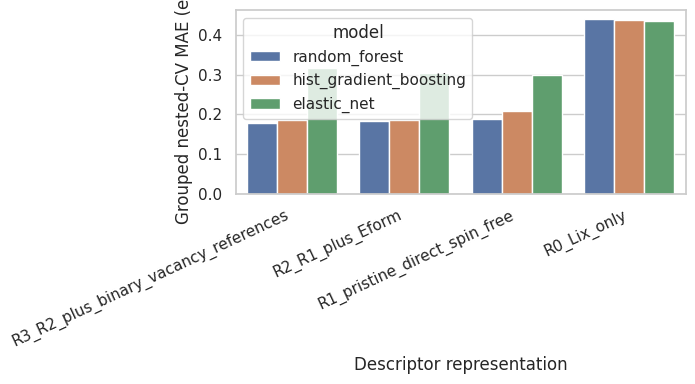

In [12]:
EVAC_RESULTS = []
EVAC_OOF = []
EVAC_FOLDS = []
EVAC_SELECTION = []

oof, result = dummy_grouped_oof(full, 'Evac', 'Evac_pristine_main')
EVAC_OOF.append(oof); EVAC_RESULTS.append(result)

for representation_name in ['R0_Lix_only', 'R1_pristine_direct_spin_free',
                            'R2_R1_plus_Eform', 'R3_R2_plus_binary_vacancy_references']:
    for model_name in ['elastic_net', 'random_forest', 'hist_gradient_boosting']:
        oof, folds, selection, result = nested_evaluate(
            full, REPRESENTATIONS[representation_name], 'Evac', model_name, representation_name
        )
        EVAC_OOF.append(oof); EVAC_FOLDS.append(folds); EVAC_SELECTION.append(selection); EVAC_RESULTS.append(result)

evac_results = pd.DataFrame(EVAC_RESULTS).sort_values(['MAE', 'RMSE'])
display(evac_results)
evac_results.to_csv(RESULTS_DIR / 'evac_main_model_summary.csv', index=False)
evac_oof = pd.concat(EVAC_OOF, ignore_index=True)
evac_oof.to_csv(RESULTS_DIR / 'evac_main_oof_predictions.csv', index=False)
pd.concat(EVAC_FOLDS, ignore_index=True).to_csv(RESULTS_DIR / 'evac_main_fold_details.csv', index=False)
evac_selection = pd.concat(EVAC_SELECTION, ignore_index=True)
evac_selection.to_csv(RESULTS_DIR / 'evac_main_selected_features.csv', index=False)

plt.figure(figsize=(7, 4))
plot_df = evac_results.query("model != 'mean_only_dummy'")
sns.barplot(data=plot_df, x='analysis', y='MAE', hue='model')
plt.xticks(rotation=25, ha='right')
plt.ylabel('Grouped nested-CV MAE (eV)')
plt.xlabel('Descriptor representation')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'evac_main_MAE_comparison.png', dpi=250)
plt.show()

## Analysis 3 — Spin-descriptor sensitivity (not the primary representation)

This test asks a narrow modeling question: do the two compressed pristine spin descriptors (`3S`, `tot_S`) materially change grouped-CV performance relative to R1? It does **not** establish that a 0 K spin summary is a transferable operating-condition descriptor, nor does it test convergence of the underlying magnetic states. Those are distinct electronic-structure questions requiring targeted calculations.

In [13]:
SPIN_RESULTS = []
SPIN_OOF = []
SPIN_FOLDS = []
SPIN_SELECTION = []

for representation_name in ['R1_pristine_direct_spin_free', 'R1_spin_sensitivity']:
    for model_name in ['elastic_net', 'random_forest', 'hist_gradient_boosting']:
        oof, folds, selection, result = nested_evaluate(
            full, REPRESENTATIONS[representation_name], 'Evac', model_name, representation_name
        )
        SPIN_OOF.append(oof); SPIN_FOLDS.append(folds); SPIN_SELECTION.append(selection); SPIN_RESULTS.append(result)

spin_results = pd.DataFrame(SPIN_RESULTS).sort_values(['model', 'MAE'])
display(spin_results)
spin_results.to_csv(RESULTS_DIR / 'spin_sensitivity_summary.csv', index=False)
pd.concat(SPIN_OOF, ignore_index=True).to_csv(RESULTS_DIR / 'spin_sensitivity_oof_predictions.csv', index=False)
pd.concat(SPIN_FOLDS, ignore_index=True).to_csv(RESULTS_DIR / 'spin_sensitivity_fold_details.csv', index=False)
pd.concat(SPIN_SELECTION, ignore_index=True).to_csv(RESULTS_DIR / 'spin_sensitivity_selected_features.csv', index=False)

,MAE,RMSE,MedianAE,R2,Bias_prediction_minus_DFT,MAE_CI_2.5%,MAE_bootstrap_median,MAE_CI_97.5%,analysis,target,model,n_oof_predictions
0,0.298649,0.440596,0.204882,0.672304,0.005307,0.265511,0.298212,0.335856,R1_pristine_direct_spin_free,Evac,elastic_net,1593
3,0.299296,0.441021,0.205748,0.671671,0.006065,0.266367,0.298930,0.336388,R1_spin_sensitivity,Evac,elastic_net,1593
2,0.209769,0.389023,0.123057,0.744529,0.020685,0.175500,0.208341,0.252034,R1_pristine_direct_spin_free,Evac,hist_gradient_boosting,1593
5,0.209887,0.389154,0.123086,0.744357,0.020271,0.175545,0.208460,0.252189,R1_spin_sensitivity,Evac,hist_gradient_boosting,1593
4,0.187138,0.331824,0.113921,0.814132,0.013009,0.160639,0.186356,0.219592,R1_spin_sensitivity,Evac,random_forest,1593
1,0.187934,0.332396,0.113921,0.813490,0.013375,0.161439,0.187150,0.220248,R1_pristine_direct_spin_free,Evac,random_forest,1593


In [14]:
# A compact, directly readable check of whether the two added spin summaries
# survived fold-wise selection. This reports descriptor utility only; it does
# not test magnetic-state convergence of the underlying DFT calculations.
spin_selected = pd.concat(SPIN_SELECTION, ignore_index=True)
for feature in ['3S', 'tot_S']:
    n_selected = int((spin_selected['feature'] == feature).sum())
    print(f'{feature}: selected in {n_selected} outer folds')

3S: selected in 0 outer folds
tot_S: selected in 0 outer folds


## Analysis 4 — Compact, reproducible descriptor selection and stability

This section addresses feature-selection robustness without treating every available method as a competing definition of “importance.”

1. A Spearman matrix identifies strongly redundant descriptor clusters.
2. Mutual-information selection occurs inside every nested-CV training fold (already recorded above).
3. The frequency with which each feature survives fold-wise selection is reported as a stability measure.
4. Held-out permutation importance is calculated after fitting the selected primary model. It is explanatory, conditional on the model and correlated feature set; it is not a causal ranking.

PCA and SHAP can be used as secondary diagnostics, but neither determines the manuscript feature set.

In [15]:
R1_NUMERIC = full[R1].copy()
spearman = R1_NUMERIC.corr(method='spearman')
high_pairs = []
for i, c1 in enumerate(spearman.columns):
    for c2 in spearman.columns[i + 1:]:
        rho = spearman.loc[c1, c2]
        if abs(rho) >= 0.90:
            high_pairs.append({'feature_1': c1, 'feature_2': c2, 'spearman_rho': rho})
high_pairs = pd.DataFrame(high_pairs).sort_values('spearman_rho', key=np.abs, ascending=False)
print('Highly correlated R1 pairs (|Spearman rho| >= 0.90):', len(high_pairs))
display(high_pairs.head(30))
high_pairs.to_csv(RESULTS_DIR / 'R1_high_spearman_pairs.csv', index=False)

primary_selection = evac_selection.query("analysis == 'R1_pristine_direct_spin_free' and model == 'random_forest'")
selection_stability = (primary_selection['feature'].value_counts()
                       .rename_axis('feature').reset_index(name='n_outer_folds_selected'))
selection_stability['selection_fraction'] = selection_stability['n_outer_folds_selected'] / (OUTER_SPLITS * OUTER_REPEATS)
display(selection_stability)
selection_stability.to_csv(RESULTS_DIR / 'R1_random_forest_selection_stability.csv', index=False)

Highly correlated R1 pairs (|Spearman rho| >= 0.90): 78


,feature_1,feature_2,spearman_rho
7,nelect,nelect_no_o,1.000000
72,M2_min_pol,M2_pol,1.000000
50,sum_chi,avg_chi,1.000000
71,M1_min_pol,M1_pol,1.000000
73,M3_min_pol,M3_pol,1.000000
12,nelect_m_only,wtd_nelect,0.999998
21,avg_M_charge,sum_qm-qo,0.999879
22,avg_M_charge,total_LCE_charge,0.999850
40,Vm,Eoxm,0.999803
28,sum_qm-qo,total_LCE_charge,0.999562


,feature,n_outer_folds_selected,selection_fraction
0,O_charge,15,1.000000
1,Vm-o,15,1.000000
2,Eoxm,15,1.000000
3,Vm,15,1.000000
4,sum_qm-qo,12,0.800000
5,LCE_avg_intensity,10,0.666667
6,avg_M_charge,9,0.600000
7,total_LCE_charge,9,0.600000
8,3Z,6,0.400000
9,occ_bc_diff,6,0.400000


In [16]:
def heldout_permutation_importance(df, features, target='Evac', model_name='random_forest'):
    """Permutation importance on outer test folds, after in-fold tuning/selection."""
    rows = []
    for repeat, fold, tr, te in outer_splits(df):
        train, test = df.iloc[tr].copy(), df.iloc[te].copy()
        pipe, params = build_pipeline(model_name, len(features))
        search = RandomizedSearchCV(
            pipe, params, n_iter=min(N_SEARCH, np.prod([len(v) for v in params.values()])),
            scoring='neg_mean_absolute_error', cv=inner_group_cv(train),
            random_state=SEED + repeat * 100 + fold, n_jobs=-1, refit=True, error_score='raise'
        )
        search.fit(train[features], train[target], groups=train.parent_id)
        # Permute original feature columns through the fitted pipeline.  The score
        # decrease is conditional on correlated columns remaining in the model.
        imp = permutation_importance(
            search.best_estimator_, test[features], test[target], n_repeats=15 if RUN_MODE == 'pilot' else 40,
            random_state=SEED + repeat * 100 + fold, scoring='neg_mean_absolute_error', n_jobs=-1
        )
        rows.extend({
            'repeat': repeat, 'fold': fold, 'feature': feature,
            'permutation_importance_MAE_increase': value
        } for feature, value in zip(features, imp.importances_mean))
    return pd.DataFrame(rows)


permutation_df = heldout_permutation_importance(full, R1)
permutation_summary = (permutation_df.groupby('feature', as_index=False)
                       .agg(mean_MAE_increase=('permutation_importance_MAE_increase', 'mean'),
                            sd_MAE_increase=('permutation_importance_MAE_increase', 'std'))
                       .sort_values('mean_MAE_increase', ascending=False))
display(permutation_summary.head(20))
permutation_df.to_csv(RESULTS_DIR / 'R1_heldout_permutation_importance_by_fold.csv', index=False)
permutation_summary.to_csv(RESULTS_DIR / 'R1_heldout_permutation_importance_summary.csv', index=False)

,feature,mean_MAE_increase,sd_MAE_increase
64,O_charge,2.460917e-01,7.358659e-02
8,LCE_avg_intensity,9.127708e-02,7.086238e-02
67,Vm-o,6.277100e-02,3.244517e-02
66,Vm,5.516433e-02,1.922377e-02
7,Eoxm,4.800983e-02,1.389780e-02
87,occ_bc_diff,3.230428e-02,4.759983e-02
89,sum_qm-qo,1.695990e-02,1.845798e-02
2,3Z,9.990617e-03,1.489062e-02
92,total_LCE_charge,7.980399e-03,8.381812e-03
70,avg_M_charge,6.139431e-03,7.370194e-03


## Analysis 5 — Leave-one-LCE-composition-out transfer

Random grouped splits estimate interpolation among sampled parent metal arrangements. This section is harder: it withholds one **LCE composition** at a time. It therefore asks whether a model trained without a given local chemical composition can transfer to that absent LCE chemistry.

The family is constructed directly from `structure_label`, using the unordered identities at P1–P3 (the three LCE pairs defined by the structure-generation workflow). The legacy `label` column is not used. A formal family must contain at least 10 rows and 5 independent parent metal arrangements; smaller cases are exploratory.

In [17]:
MIN_FORMAL_LOFO_ROWS = 10
MIN_FORMAL_LOFO_PARENT_IDS = 5

def lofo_evaluate(df, features, target='Evac', model_name='random_forest'):
    records, fold_info = [], []
    for family, test in df.groupby('lce_composition_family', sort=True):
        train = df[df.lce_composition_family != family].copy()
        status = ('formal' if (len(test) >= MIN_FORMAL_LOFO_ROWS
                               and test.parent_id.nunique() >= MIN_FORMAL_LOFO_PARENT_IDS)
                  else 'exploratory_small_family')
        if train.parent_id.nunique() < 2:
            continue
        pipe, params = build_pipeline(model_name, len(features))
        search = RandomizedSearchCV(
            pipe, params, n_iter=min(N_SEARCH, np.prod([len(v) for v in params.values()])),
            scoring='neg_mean_absolute_error', cv=inner_group_cv(train),
            random_state=SEED + int(hashlib.sha256(str(family).encode()).hexdigest()[:8], 16) % 10000,
            n_jobs=-1, refit=True, error_score='raise'
        )
        search.fit(train[features], train[target], groups=train.parent_id)
        pred = search.predict(test[features])
        rec = test[['source_excel_row', 'structure_label', 'parent_id', 'lce_composition_family', 'Lix']].copy()
        rec['y_true'], rec['y_pred'] = test[target].to_numpy(), pred
        rec['residual_prediction_minus_DFT'] = pred - rec['y_true']
        rec['model'], rec['status'] = model_name, status
        records.append(rec)
        fold_info.append({
            'withheld_family': family, 'status': status, 'n_test_rows': len(test),
            'n_test_parent_ids': test.parent_id.nunique(), 'MAE': mean_absolute_error(test[target], pred),
            'RMSE': np.sqrt(mean_squared_error(test[target], pred)), 'R2': r2_score(test[target], pred),
            'best_inner_MAE': -search.best_score_, 'best_params': json.dumps(search.best_params_, default=str),
        })
    return pd.concat(records, ignore_index=True), pd.DataFrame(fold_info)


lofo_oof, lofo_summary = lofo_evaluate(full, R1)
display(lofo_summary.sort_values('MAE', ascending=False))
lofo_oof.to_csv(RESULTS_DIR / 'LOFO_R1_random_forest_predictions.csv', index=False)
lofo_summary.to_csv(RESULTS_DIR / 'LOFO_R1_random_forest_summary.csv', index=False)

,withheld_family,status,n_test_rows,n_test_parent_ids,MAE,RMSE,R2,best_inner_MAE,best_params
33,LCE_Ga3,exploratory_small_family,4,1,1.458645,1.746503,-1.197826,0.169941,"{""select__k"": 8, ""model__min_samples_leaf"": 1,..."
14,LCE_Al3,formal,17,11,1.374402,1.536583,-0.002069,0.172501,"{""select__k"": 8, ""model__min_samples_leaf"": 3,..."
10,LCE_Al2_Co1,formal,28,10,0.870021,1.011963,-0.096083,0.178233,"{""select__k"": 8, ""model__min_samples_leaf"": 1,..."
18,LCE_Co1_Ga2,exploratory_small_family,12,3,0.695640,0.767126,-0.137636,0.189059,"{""select__k"": 10, ""model__min_samples_leaf"": 3..."
8,LCE_Al1_Mn2,exploratory_small_family,6,6,0.665334,0.680218,-41.871236,0.189439,"{""select__k"": 8, ""model__min_samples_leaf"": 1,..."
12,LCE_Al2_Mn1,exploratory_small_family,6,6,0.630337,0.698786,-200.459340,0.179497,"{""select__k"": 10, ""model__min_samples_leaf"": 2..."
13,LCE_Al2_Ni1,exploratory_small_family,6,6,0.627362,0.710981,-223.107755,0.179911,"{""select__k"": 5, ""model__min_samples_leaf"": 1,..."
11,LCE_Al2_Fe1,exploratory_small_family,6,6,0.606412,0.625452,-24.287015,0.191899,"{""select__k"": 4, ""model__min_samples_leaf"": 2,..."
3,LCE_Al1_Co2,formal,28,10,0.593858,0.665844,-0.363458,0.201079,"{""select__k"": 4, ""model__min_samples_leaf"": 1,..."
6,LCE_Al1_Fe2,exploratory_small_family,6,6,0.435731,0.460802,-10.966871,0.189509,"{""select__k"": 10, ""model__min_samples_leaf"": 3..."


## Analysis 6 — Matched four-lithiation panel sensitivity

Some parent metal arrangements occur at all four lithiation levels. Restricting to that balanced panel checks whether the main conclusion is driven by unbalanced composition/lithiation coverage. It is a robustness analysis; it is not a new independent dataset.

In [18]:
parent_lix_counts = full.groupby('parent_id')['Lix'].nunique()
matched_parents = parent_lix_counts[parent_lix_counts == 4].index
matched_panel = full[full.parent_id.isin(matched_parents)].copy()
print('Matched panel rows:', len(matched_panel), '| parent metal arrangements:', matched_panel.parent_id.nunique())
print('Rows per Lix:')
display(matched_panel['Lix'].value_counts().sort_index())

panel_oof, panel_folds, panel_selection, panel_result = nested_evaluate(
    matched_panel, R1, 'Evac', 'random_forest', 'R1_matched_four_Lix_panel'
)
display(pd.DataFrame([panel_result]))
panel_oof.to_csv(RESULTS_DIR / 'matched_panel_R1_random_forest_oof.csv', index=False)
panel_folds.to_csv(RESULTS_DIR / 'matched_panel_R1_random_forest_folds.csv', index=False)
panel_selection.to_csv(RESULTS_DIR / 'matched_panel_R1_random_forest_selected_features.csv', index=False)
pd.DataFrame([panel_result]).to_csv(RESULTS_DIR / 'matched_panel_R1_random_forest_summary.csv', index=False)

Matched panel rows: 260 | parent metal arrangements: 65
Rows per Lix:


,count
Lix,
0.67,65
0.78,65
0.89,65
1.00,65


,MAE,RMSE,MedianAE,R2,Bias_prediction_minus_DFT,MAE_CI_2.5%,MAE_bootstrap_median,MAE_CI_97.5%,analysis,target,model,n_oof_predictions
0,0.178392,0.311303,0.09711,0.809979,0.017112,0.137978,0.176429,0.229297,R1_matched_four_Lix_panel,Evac,random_forest,780


## Analysis 7 — Limited defect-response test (48-structure subset)

This analysis is intentionally narrower than the full-dataset pristine model. It asks whether post-vacancy descriptor changes improve prediction **within the 48 structures for which those descriptors were calculated**. It must not be generalized to the full 531-structure space.

The correct target for the correction is a *new*, cross-fitted residual:

$$r_i = E_{\mathrm{vac},i}^{\mathrm{DFT}} - \hat{E}_{\mathrm{vac},i}^{\mathrm{pristine, OOF}}.$$

The legacy `Residual` column is excluded. Target-energy columns and obvious energy-derived quantities (`Evac`, `pris_E_form`, `vac_E_form`, binary vacancy references) are also excluded from the primary response-feature model. An optional energy-inclusive diagnostic can be added later, but must be labeled as an upper bound rather than mechanistic evidence.

Because $n=48$, the default correction model is Ridge regularization. The cell is disabled by default so that the team can first inspect the printed response-feature list and choose whether this small-subset result is scientifically ready to report.

In [19]:
# Deliberately conservative primary response-feature definition.
DEFECT_RESPONSE_EXCLUDE = {
    'label', 'Modification', 'Evac', 'Residual', 'source_excel_row', 'vac_source_excel_row',
    'structure_label', 'parent_id', 'plot_label', 'lce_composition_family', 'pris_E_form', 'vac_E_form',
    'avg_bin_evac', 'pris_nelect', 'vac_nelect', 'Lix'
}

vac_numeric = vac.select_dtypes(include=np.number).columns.tolist()
RESPONSE_FEATURES = [c for c in vac_numeric if c not in DEFECT_RESPONSE_EXCLUDE]

# Keep only quantities that explicitly describe the vacancy state or the
# pristine-to-vacancy change. This prevents a generic pristine descriptor from
# masquerading as a response descriptor.
RESPONSE_FEATURES = [c for c in RESPONSE_FEATURES if c.startswith('vac_') or c.startswith('delta_')]

print('Vacancy-subset rows:', len(vac))
print('Primary defect-response features (review before enabling):')
print(RESPONSE_FEATURES)
assert 'Residual' not in RESPONSE_FEATURES
assert 'Evac' not in RESPONSE_FEATURES
assert 'vac_E_form' not in RESPONSE_FEATURES

Vacancy-subset rows: 48
Primary defect-response features (review before enabling):
['vac_Ef', 'vac_bg', 'delta_Ef', 'delta_bg', 'delta_avg_bc', 'delta_avg_bw', 'delta_sum_bc', 'delta_sum_bw', 'delta_bc_occ', 'delta_bw_occ', 'delta_bc_21', 'delta_bc_23', 'delta_bc_25']


In [20]:
def fit_pristine_base_and_predict(train_full, predict_features, features=R1):
    """Fit the fixed primary pristine model for an internal cross-fit.

    For computational tractability in the 48-row diagnostic, this uses a
    regularized Ridge base model and in-fold imputation/scaling. The main
    manuscript-quality pristine benchmark remains the nested RF analysis above.
    """
    pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('model', Ridge(alpha=10.0)),
    ])
    pipe.fit(train_full[features], train_full['Evac'])
    return pipe.predict(predict_features)


def defect_residual_crossfit(full_df, vac_df, response_features):
    """Strict outer-fold evaluation of an additive defect-response correction.

    Each held-out vacancy-subset fold receives a pristine prediction from a base
    model trained without its parent groups. Within the outer training subset,
    residual labels are cross-fitted before Ridge learns the response correction.
    """
    # Prefix the pristine descriptor copy to make provenance explicit and avoid
    # ambiguity with the separate post-vacancy quantities in `vac_df`.
    pristine_copy = full_df[['source_excel_row', 'Evac'] + R1].copy()
    pristine_copy = pristine_copy.rename(columns={
        'Evac': 'Evac_pristine_table', **{f: f'base__{f}' for f in R1}
    })
    merged = vac_df.merge(pristine_copy, on='source_excel_row', how='left', validate='one_to_one')
    assert len(merged) == len(vac_df), 'Vacancy rows did not map one-to-one to full data.'
    records = []
    split_count = min(5, merged.parent_id.nunique())
    splitter = GroupKFold(n_splits=split_count)
    for outer_fold, (tr, te) in enumerate(splitter.split(merged, groups=merged.parent_id)):
        outer_train, outer_test = merged.iloc[tr].copy(), merged.iloc[te].copy()
        heldout_parents = set(outer_test.parent_id)
        base_train_full = full_df[~full_df.parent_id.isin(heldout_parents)].copy()
        base_test_X = outer_test[[f'base__{f}' for f in R1]].copy()
        base_test_X.columns = R1
        base_test_pred = fit_pristine_base_and_predict(base_train_full, base_test_X, R1)

        # Cross-fit residual labels on outer-training rows. Their base prediction
        # must not be generated by a model trained on that same parent group.
        inner_splits = min(4, outer_train.parent_id.nunique())
        inner = GroupKFold(n_splits=inner_splits)
        crossfit_pred = np.full(len(outer_train), np.nan)
        for itr, ite in inner.split(outer_train, groups=outer_train.parent_id):
            validation_parents = set(outer_train.iloc[ite].parent_id)
            inner_base_train = base_train_full[~base_train_full.parent_id.isin(validation_parents)]
            inner_test_X = outer_train.iloc[ite][[f'base__{f}' for f in R1]].copy()
            inner_test_X.columns = R1
            crossfit_pred[ite] = fit_pristine_base_and_predict(inner_base_train, inner_test_X, R1)
        assert np.isfinite(crossfit_pred).all()
        residual_target = outer_train['Evac'].to_numpy() - crossfit_pred
        correction = Pipeline([('impute', SimpleImputer(strategy='median')),
                               ('scale', StandardScaler()), ('model', Ridge(alpha=10.0))])
        correction.fit(outer_train[response_features], residual_target)
        corrected = base_test_pred + correction.predict(outer_test[response_features])
        for idx, row in outer_test.reset_index(drop=True).iterrows():
            records.append({
                'outer_fold': outer_fold, 'source_excel_row': row['source_excel_row'],
                'structure_label': row['structure_label'], 'parent_id': row['parent_id'],
                'Evac_DFT': row['Evac'], 'pristine_base_prediction': base_test_pred[idx],
                'corrected_prediction': corrected[idx],
            })
    return pd.DataFrame(records)


if RUN_DEFECT_RESIDUAL_ANALYSIS:
    defect_oof = defect_residual_crossfit(full, vac, RESPONSE_FEATURES)
    defect_summary = pd.DataFrame([
        {'model': 'pristine_base_on_48_subset', **metrics(defect_oof.Evac_DFT, defect_oof.pristine_base_prediction)},
        {'model': 'pristine_base_plus_response_Ridge', **metrics(defect_oof.Evac_DFT, defect_oof.corrected_prediction)},
    ])
    display(defect_summary)
    defect_oof.to_csv(RESULTS_DIR / 'defect_response_crossfit_predictions.csv', index=False)
    defect_summary.to_csv(RESULTS_DIR / 'defect_response_crossfit_summary.csv', index=False)
else:
    print('Defect-response analysis is disabled. Review RESPONSE_FEATURES, then set RUN_DEFECT_RESIDUAL_ANALYSIS = True and rerun this section.')

Defect-response analysis is disabled. Review RESPONSE_FEATURES, then set RUN_DEFECT_RESIDUAL_ANALYSIS = True and rerun this section.


## Mechanistic charge-response analysis: separate evidence stream

The manuscript’s LCE/nonLCE/O electronic-response analysis remains a physical-chemistry analysis, not a direct extension of the 48-row defect-descriptor model above. The normalized PDOS-derived $\Delta e$ values describe relative partitioning of changes in projected electronic occupation; they are not conserved real-space charge fractions.

When the underlying table for the representative systems is available, add a separate section here to:

1. reproduce the response topology plots and grouped table;
2. compare qualitative response topologies with `Evac` without imposing one-to-one correspondence;
3. add Bader charge, charge-density-difference, and/or local-moment checks for representative systems, if completed;
4. state explicitly whether those independent analyses support the qualitative PDOS response partitioning.

Do not add a claim that LOFO residuals uniquely prove that defect-response physics is the missing information. A composition-dependent defect response is a plausible, independently analyzable source of information not uniquely represented by the compact pristine descriptor set.

## Final reporting checklist

Before using results in the revision, archive the result directory and answer these questions explicitly:

- Does the data audit match the expected 531-row curated full dataset and 48-row vacancy subset?
- Does the P1–P3 LCE-composition definition match the structure-generation record? This notebook uses it, not the legacy plotting label, for leave-one-LCE-composition-out validation.
- Is `E_form` substantially easier to predict than `Evac` from pristine descriptors?
- Which physically defined representation gives the best grouped interpolation performance, and are differences larger than their group-bootstrap uncertainty?
- Does LOFO transfer deteriorate relative to grouped interpolation? Report this as a domain-of-applicability result, not as a failure of the model.
- Does adding the compressed spin summary materially change accuracy? If so, discuss it only as 0 K descriptor sensitivity.
- Are compact-feature selections stable across outer folds and consistent with, rather than contradicted by, held-out permutation results?
- Does the 48-row response model show a reproducible, limited-subset improvement? If not, report that the available response descriptors do not materially improve the model on that subset.
- Keep the manuscript distinction clear: demonstrated dataset results, literature-established methodological context, and chemical inference are different evidentiary levels.

In [21]:
# Create a concise inventory that can be shared with collaborators along with
# the numerical CSVs and PNG figures.
inventory = pd.DataFrame({
    'file': sorted(p.name for p in RESULTS_DIR.iterdir()),
    'bytes': [p.stat().st_size for p in sorted(RESULTS_DIR.iterdir())],
})
display(inventory)
inventory.to_csv(RESULTS_DIR / 'output_inventory.csv', index=False)
print('Notebook run complete. Inspect outputs before interpreting them in the manuscript.')

,file,bytes
0,LOFO_R1_random_forest_predictions.csv,103701
1,LOFO_R1_random_forest_summary.csv,8508
2,R1_heldout_permutation_importance_by_fold.csv,52816
3,R1_heldout_permutation_importance_summary.csv,5350
4,R1_high_spearman_pairs.csv,2984
5,R1_random_forest_selection_stability.csv,226
6,audit_summary.csv,161
7,eform_fold_details.csv,9182
8,eform_model_summary.csv,947
9,eform_oof_predictions.csv,1420425


Notebook run complete. Inspect outputs before interpreting them in the manuscript.


In [22]:
import shutil
from pathlib import Path
from google.colab import files

# Confirm that this is the manuscript-quality result folder.
print("Results folder:", RESULTS_DIR.resolve())
print("Files:", len(list(RESULTS_DIR.iterdir())))

# Create and download one archive containing all numerical outputs.
archive_path = shutil.make_archive(
    "oxygen_vacancy_ml_results_manuscript",
    "zip",
    root_dir=RESULTS_DIR,
)
print("Created:", archive_path)

files.download(archive_path)

Results folder: /content/oxygen_vacancy_ml_results_manuscript
Files: 26
Created: /content/oxygen_vacancy_ml_results_manuscript.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>